In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.io as io
import os

# Define your device (for GPU processing)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device: ", device)

transform = transforms.Compose([
    # transforms.ToPILImage(),
    transforms.Resize((128, 128)),  # Resize frames to 128x128
    transforms.ToTensor(),  # Convert frames to tensor format
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize the RGB channels
])

Device:  cuda


In [2]:
from sklearn.model_selection import train_test_split
import os

class VideoDataset(Dataset):
    def __init__(self, root_dir, transform=None, max_frames=240, train=True, test_size=0.2):
        self.root_dir = root_dir
        self.transform = transform
        self.max_frames = max_frames
        self.classes = ['non_violent', 'violent']
        self.data = []

        # Load all data
        for label, class_name in enumerate(self.classes):
            class_dir = os.path.join(root_dir, class_name)
            for cam_folder in os.listdir(class_dir):
                cam_dir = os.path.join(class_dir, cam_folder)
                if os.path.isdir(cam_dir):
                    for video_name in os.listdir(cam_dir):
                        if video_name.endswith('.mp4'):
                            video_path = os.path.join(cam_dir, video_name)
                            self.data.append((video_path, label))

        # Split data into training and testing sets
        train_data, test_data = train_test_split(self.data, test_size=test_size, stratify=[x[1] for x in self.data])

        # Select either train or test data
        if train:
            self.data = train_data
        else:
            self.data = test_data

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        video_path, label = self.data[idx]
        
        # Load the video and process frames as you already do
        video, _, _ = io.read_video(video_path, pts_unit='sec')

        # Perform the padding or truncating of frames
        total_frames = video.shape[0]
        if total_frames < self.max_frames:
            padded_video = torch.zeros((self.max_frames, video.shape[1], video.shape[2], video.shape[3]), dtype=video.dtype)
            padded_video[:total_frames] = video
            video = padded_video
        else:
            video = video[:self.max_frames]

        # Apply transformations
        pil_transform = transforms.ToPILImage()
        frames = [self.transform(pil_transform(frame.permute(2, 0, 1))) for frame in video] if self.transform else video
        video = torch.stack(frames).permute(1, 0, 2, 3).to(device)
        label = torch.tensor(label).to(device)
        return video, label


In [3]:
path ='/home/idealab/MAIN PROJECT GROUP 15 ECA/Automatic-Violence-Detection/A-Dataset-for-Automatic-Violence-Detection-in-Videos/violence-detection-dataset'
# train_dataset = VideoDataset(root_dir=path, transform=transform)

# Create data loaders
# train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=5, shuffle=True)
train_dataset = VideoDataset(root_dir=path, transform=transform, train=True, test_size=0.2)
test_dataset = VideoDataset(root_dir=path, transform=transform, train=False, test_size=0.2)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

# Iterate through the data loader
i = 1
for videos, labels in train_loader:
    print(videos.shape)  # Should print shape [batch_size, frames, channels, height, width]
    print(labels)        # Should print corresponding labels (0 for non-violent, 1 for violent)
    print(i)
    i+=8
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)


torch.Size([8, 3, 240, 128, 128])
tensor([1, 1, 1, 1, 1, 1, 0, 1], device='cuda:0')
1
torch.Size([8, 3, 240, 128, 128])
tensor([1, 0, 0, 1, 1, 1, 1, 1], device='cuda:0')
9
torch.Size([8, 3, 240, 128, 128])
tensor([1, 1, 1, 1, 1, 1, 1, 1], device='cuda:0')
17
torch.Size([8, 3, 240, 128, 128])
tensor([1, 1, 1, 1, 0, 0, 1, 1], device='cuda:0')
25
torch.Size([8, 3, 240, 128, 128])
tensor([1, 1, 0, 1, 1, 1, 1, 1], device='cuda:0')
33
torch.Size([8, 3, 240, 128, 128])
tensor([0, 1, 0, 0, 0, 0, 0, 1], device='cuda:0')
41
torch.Size([8, 3, 240, 128, 128])
tensor([1, 0, 1, 0, 1, 1, 0, 1], device='cuda:0')
49
torch.Size([8, 3, 240, 128, 128])
tensor([1, 1, 1, 1, 1, 0, 0, 1], device='cuda:0')
57
torch.Size([8, 3, 240, 128, 128])
tensor([1, 1, 1, 1, 1, 0, 1, 0], device='cuda:0')
65
torch.Size([8, 3, 240, 128, 128])
tensor([1, 1, 1, 1, 0, 1, 0, 1], device='cuda:0')
73
torch.Size([8, 3, 240, 128, 128])
tensor([1, 1, 1, 0, 1, 1, 0, 1], device='cuda:0')
81
torch.Size([8, 3, 240, 128, 128])
tensor([1, 

In [4]:
import torch.nn as nn
from torchvision.models.video import mc3_18, MC3_18_Weights

# Load the pre-trained ResNet3D-18 model with the new weights system
weights = MC3_18_Weights.DEFAULT  # Using default pre-trained weights
model = mc3_18(weights=weights)

# Modify the last fully connected layer for 2 classes (binary classification)
model.fc = nn.Linear(in_features=model.fc.in_features, out_features=2)

# Freeze all layers except the final fully connected layer
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the final fully connected layer
for param in model.fc.parameters():
    param.requires_grad = True

# Move the model to the appropriate device (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)  # Only train final layer
# train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
save_dir = "checkpoints1"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Function to save the model and optimizer state
def save_checkpoint(model, optimizer, epoch, filename="model_checkpoint.pth"):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }
    save_path = os.path.join(save_dir, filename)
    torch.save(checkpoint, save_path)
    print(f"Checkpoint saved at {save_path}")


In [7]:
num_epochs = 35
train_losses = []
val_losses = []
val_accuracies = []
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for videos, labels in train_loader:
        videos, labels = videos.to(device), labels.to(device)
        
        # Zero the parameter gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(videos)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * videos.size(0)
    save_checkpoint(model, optimizer, epoch, filename=f"model_epoch_{epoch}.pth")
    avg_train_loss = running_loss / len(train_loader.dataset)  # Average training loss
    train_losses.append(avg_train_loss)
    # Validation phase
    # avg_val_loss, val_accuracy = validate(model, test_loader, criterion)
    # val_losses.append(avg_val_loss)  # Store validation loss
    # val_accuracies.append(val_accuracy)  # Store validation accuracy
    
    # Print statistics
    print(f"Epoch [{epoch+1}/{num_epochs}], "
          f"Train Loss: {avg_train_loss}, ")
final_model_path = os.path.join(save_dir, "final_model.pth")
torch.save(model.state_dict(), final_model_path)
print(f"Final model saved at {final_model_path}")

Checkpoint saved at checkpoints1/model_epoch_0.pth
Epoch [1/35], Train Loss: 0.6434801825455256, 
Checkpoint saved at checkpoints1/model_epoch_1.pth
Epoch [2/35], Train Loss: 0.5916320145130157, 
Checkpoint saved at checkpoints1/model_epoch_2.pth
Epoch [3/35], Train Loss: 0.5580869998250689, 
Checkpoint saved at checkpoints1/model_epoch_3.pth
Epoch [4/35], Train Loss: 0.5465942365782601, 
Checkpoint saved at checkpoints1/model_epoch_4.pth
Epoch [5/35], Train Loss: 0.518770797763552, 
Checkpoint saved at checkpoints1/model_epoch_5.pth
Epoch [6/35], Train Loss: 0.523350965976715, 
Checkpoint saved at checkpoints1/model_epoch_6.pth
Epoch [7/35], Train Loss: 0.46269882832254683, 
Checkpoint saved at checkpoints1/model_epoch_7.pth
Epoch [8/35], Train Loss: 0.46982810326984953, 
Checkpoint saved at checkpoints1/model_epoch_8.pth
Epoch [9/35], Train Loss: 0.4502535104751587, 
Checkpoint saved at checkpoints1/model_epoch_9.pth
Epoch [10/35], Train Loss: 0.41916880437306, 
Checkpoint saved at c

In [8]:
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for videos, labels in test_loader:
        videos, labels = videos.to(device), labels.to(device)
        outputs = model(videos)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f'Accuracy: {100 * correct / total}%')


Accuracy: 95.71428571428571%


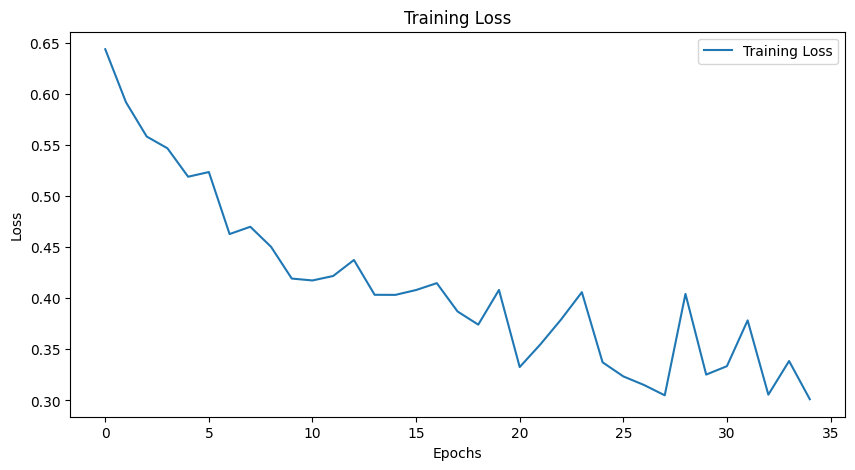

In [9]:
import matplotlib.pyplot as plt

# Plotting Training and Validation Loss
plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Training Loss')
# plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

# Plotting Validation Accuracy
# plt.figure(figsize=(10,5))
# plt.plot(val_accuracies, label='Validation Accuracy')
# plt.xlabel('Epochs')
# plt.ylabel('Accuracy')
# plt.title('Validation Accuracy')
# plt.legend()
# plt.show()


In [5]:
from torch.cuda.amp import autocast

def validate_model(model, val_loader, criterion, device):
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            with autocast():  # Use mixed precision
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    avg_val_loss = val_loss / len(val_loader)
    
    return avg_val_loss, accuracy
import torch.nn as nn
# Directory containing model checkpoints
checkpoint_dir = 'checkpoints1'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_epochs = 35
criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)  # Only train final layer
criterion = torch.nn.CrossEntropyLoss()  # or any other loss function
val_losses = []
val_accuracies = []
# Iterate through each checkpoint
for epoch in range(num_epochs):  # Replace num_epochs with the total number of epochs you saved
    checkpoint_path = os.path.join(checkpoint_dir, f'model_epoch_{epoch}.pth')
    torch.cuda.empty_cache()
    # Load the checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])

    # Validate the model on the validation set
    val_loss, val_accuracy = validate_model(model, test_loader, criterion, device)

    print(f'Epoch {epoch}: Validation Loss = {val_loss}, Validation Accuracy = {val_accuracy}%')
    val_losses.append(val_loss)  # Store validation loss
    val_accuracies.append(val_accuracy)  # Store validation accuracy
    # Optionally, unload the model from memory
    del checkpoint
    torch.cuda.empty_cache()  # Clear GPU memory (optional, if you're running on GPU)


/tmp/ipykernel_208679/763846640.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)
/tmp/ipykernel_208679/7638

Epoch 0: Validation Loss = 0.5764917433261871, Validation Accuracy = 65.71428571428571%
Epoch 1: Validation Loss = 0.5551011827256944, Validation Accuracy = 88.57142857142857%
Epoch 2: Validation Loss = 0.5310352477762434, Validation Accuracy = 87.14285714285714%
Epoch 3: Validation Loss = 0.5734705064031813, Validation Accuracy = 71.42857142857143%
Epoch 4: Validation Loss = 0.49445837404992843, Validation Accuracy = 65.71428571428571%
Epoch 5: Validation Loss = 0.44332094656096566, Validation Accuracy = 75.71428571428571%
Epoch 6: Validation Loss = 0.42631982763608295, Validation Accuracy = 91.42857142857143%
Epoch 7: Validation Loss = 0.40334828694661456, Validation Accuracy = 91.42857142857143%
Epoch 8: Validation Loss = 0.39262474907769096, Validation Accuracy = 84.28571428571429%
Epoch 9: Validation Loss = 0.39112910628318787, Validation Accuracy = 91.42857142857143%
Epoch 10: Validation Loss = 0.3727959526909722, Validation Accuracy = 92.85714285714286%
Epoch 11: Validation Loss

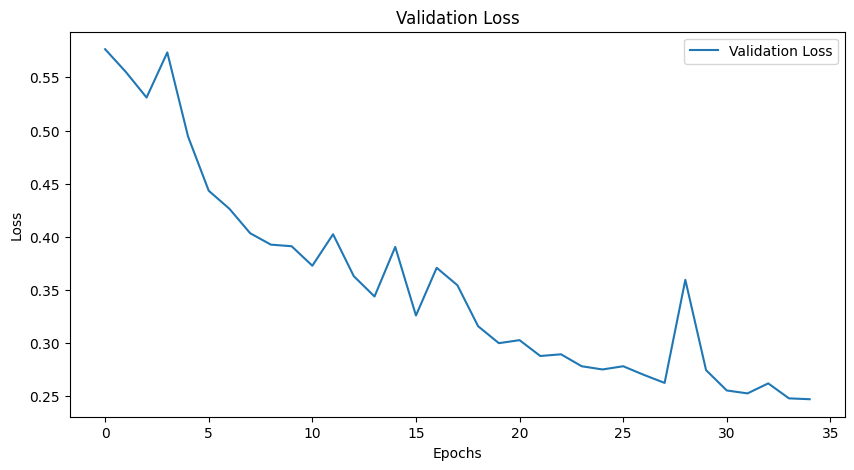

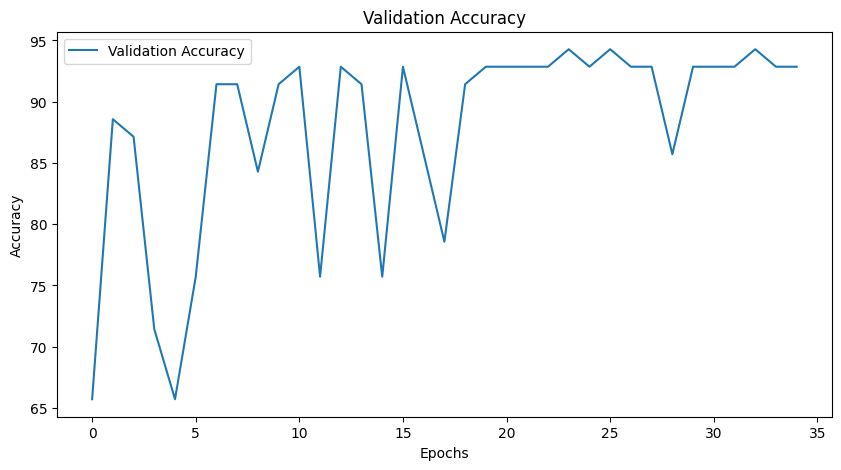

In [6]:
import matplotlib.pyplot as plt

# Plotting Training and Validation Loss
plt.figure(figsize=(10,5))
# plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Validation Loss')
plt.legend()
plt.show()

# Plotting Validation Accuracy
plt.figure(figsize=(10,5))
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy')
plt.legend()
plt.show()

In [9]:
del model 
torch.cuda.empty_cache()

In [10]:
del weights